In [2]:
import pandas as pd

# oyuncular_temiz.csv dosyasını yükleme
df_oyuncular = pd.read_csv('../../data/processed/oyuncular_temiz.csv')

print("✅ Oyuncular verileri başarıyla yüklendi!")
print(f"Şekil: {df_oyuncular.shape}")
display(df_oyuncular.head())

✅ Oyuncular verileri başarıyla yüklendi!
Şekil: (111, 17)


,oyuncu_cinsiyet,oyuncu_yas,oyuncu_gunluk_sure,oyuncu_cihaz,oyuncu_oyun_turu,oyuncu_harcama_butcesi,oyuncu_harcama_etkisi,oyuncu_maglubiyet_tepkisi,oyuncu_motivasyon,oyuncu_stres_etkisi,oyuncu_uyku_feragati,oyuncu_ruh_hali,oyuncu_pegi_dikkat,oyuncu_platform_kisitlama_gorus,oyuncu_harcama_amaci,oyuncu_haftalik_oyun_gunu,oyuncu_ebeveyn_onay_gorus
0,Erkek,29-35,1-3 saat,"Kişisel Bilgisayar (Masaüstü, Laptop - Steam, ...","Rekabetçi Nişancı & Battle Royale (Valorant, C...",Hiç harcama yapmam,Hiç harcamam veya sınırlarımı asla aşmam.,Biraz moralim bozulur ama oyuna ara veririm.,Sadece eğlenmek ve vakit geçirmek,"Tamamen rahatlatır, stresimi alır.",Hiçbir zaman,"Hiç etkilemez, anında unuturum.","Evet, her zaman",Kesinlikle destekliyorum,Oyun içi harcama yapmam.,Neredeyse her gün / Her gün,Kesinlikle destekliyorum
1,Kadın,18-22,1-3 saat,"Mobil Cihaz (Akıllı Telefon, Tablet)","Strateji & MOBA (League of Legends - LoL, Clas...",250 TL'den az,Hiç harcamam veya sınırlarımı asla aşmam.,Hırslanırım ve mutlaka kazanana kadar peş peşe...,"Gerçek hayatın stresinden, sorunlarından uzakl...","Oynadığım sürece rahatlarım, kafam dağıtır.",Nadiren (Ayda 1-2 kez),Sadece anlık olarak canım sıkılır.,"Hayır, dikkat etmiyorum",Desteklemiyorum,"İçeriği belli olan, doğrudan istediğim bir eşy...",Sıklıkla (Haftada 3-4 kez),Kesinlikle destekliyorum
2,Erkek,18-22,1-3 saat,"Mobil Cihaz (Akıllı Telefon, Tablet)","Basit Eğlence / Bulmaca (Candy Crush, Kelime O...",250 TL'den az,Hiç harcamam veya sınırlarımı asla aşmam.,Sakince oyunu kapatır veya başka bir işe geçerim.,Sadece eğlenmek ve vakit geçirmek,"Tamamen rahatlatır, stresimi alır.",Hiçbir zaman,"Hiç etkilemez, anında unuturum.","Evet, her zaman",Kesinlikle destekliyorum,Oyun içi harcama yapmam.,Hiçbir zaman,Kesinlikle destekliyorum
3,Erkek,23-28,1-3 saat,"Kişisel Bilgisayar (Masaüstü, Laptop - Steam, ...","Rekabetçi Nişancı & Battle Royale (Valorant, C...",250 TL'den az,Hiç harcamam veya sınırlarımı asla aşmam.,Sakince oyunu kapatır veya başka bir işe geçerim.,Sadece eğlenmek ve vakit geçirmek,"Tamamen rahatlatır, stresimi alır.",Nadiren (Ayda 1-2 kez),"Hiç etkilemez, anında unuturum.",Bazen,Kesinlikle desteklemiyorum,Oyunda daha hızlı ilerlemek veya diğer oyuncul...,Nadiren (Ayda 1-2 kez),Destekliyorum
4,Erkek,18-22,1-3 saat,"Kişisel Bilgisayar (Masaüstü, Laptop - Steam, ...","Basit Eğlence / Bulmaca (Candy Crush, Kelime O...",Hiç harcama yapmam,Bazen limitimi aşarım ama bütçemi sarsmaz.,Sadece kaybımı telafi etmek için bir maç daha ...,Sosyalleşmek ve arkadaşlarımla olmak,Nötr (Oynamak veya oynamamak genel ruh halimi ...,Hiçbir zaman,Sadece anlık olarak canım sıkılır.,PEGI nedir bilmiyorum,Kesinlikle desteklemiyorum,Oyun içi harcama yapmam.,Nadiren (Ayda 1-2 kez),Kesinlikle destekliyorum


In [3]:
# -------------------------------------------------------------------
# BÖLÜM 1: Senin Atadığın Sayısal Dönüşümler (Asla bozulmayan kısım)
# -------------------------------------------------------------------
sozluk_haritasi = {
    'oyuncu_yas': {
        '18-22': 0, '23-28': 1, '29-35': 2, '36-45': 3, '46-55': 4, '55+': 5
    },
    'oyuncu_haftalik_oyun_gunu': {
        'Hiçbir zaman': 0, 'Nadiren (Ayda 1-2 kez)': 1, 'Bazen (Haftada 1-2 kez)': 2, 
        'Sıklıkla (Haftada 3-4 kez)': 3, 'Neredeyse her gün / Her gün': 4
    },
    'oyuncu_gunluk_sure': {
        '1 saatten az': 0, '1-3 saat': 1, '3-5 saat': 2, '5 saatten fazla': 3
    },
    'oyuncu_harcama_butcesi': {
        'Hiç harcama yapmam': 0, "250 TL'den az": 1, '250 - 1000 TL arası': 2, '1000 TL ve üzeri': 3
    },
    'oyuncu_maglubiyet_tepkisi': {
        'Sakince oyunu kapatır veya başka bir işe geçerim.': 0, 
        'Biraz moralim bozulur ama oyuna ara veririm.': 1, 
        'Sadece kaybımı telafi etmek için bir maç daha atar, sonra çıkarım.': 2, 
        'Hırslanırım ve mutlaka kazanana kadar peş peşe yeni maçlara girmeye devam ederim.': 3,
        'Sinirimden saatlerce bilgisayarın/telefonun başından kalkamam.': 4
    },
    'oyuncu_uyku_feragati': {
        'Hiçbir zaman': 0, 'Nadiren (Ayda 1-2 kez)': 1, 'Bazen (Ayda birkaç kez)': 2, 
        'Sıklıkla (Haftada birkaç kez)': 3, 'Neredeyse her gün': 4
    },
    'oyuncu_ruh_hali': {
        'Hiç etkilemez, anında unuturum.': 0, 'Sadece anlık olarak canım sıkılır.': 1, 
        'O günkü genel moralimi düşürür.': 2, 'Çevreme karşı gergin ve tahammülsüz olurum.': 3, 
        'Günlük hayatta öfke patlamaları yaşamama sebep olur.': 4
    },
    'oyuncu_pegi_dikkat': {
        'Evet, her zaman': 0, 'Bazen': 1, 'Hayır, dikkat etmiyorum': 2, 'PEGI nedir bilmiyorum': 3
    },
    'oyuncu_platform_kisitlama_gorus': {
        'Kesinlikle desteklemiyorum': 4, 'Desteklemiyorum': 3, 'Kararsızım': 2, 
        'Destekliyorum': 1, 'Kesinlikle destekliyorum': 0
    },
    'veli_ebeveyn_onay_gorus': { 
        'Kesinlikle desteklemiyorum': 4, 'Desteklemiyorum': 3, 'Kararsızım': 2, 
        'Destekliyorum': 1, 'Kesinlikle destekliyorum': 0
    }
}

# Belirttiğin sözlükteki atamaları DataFrame'e uyguluyoruz
df_oyuncular.replace(sozluk_haritasi, inplace=True)


# -------------------------------------------------------------------
# BÖLÜM 2: One-Hot Encoding (Kategorik verileri 1-0 yapma)
# -------------------------------------------------------------------
ohe_yapilacak_sutunlar = [
    'oyuncu_cinsiyet', 
    'oyuncu_harcama_etkisi', 
    'oyuncu_stres_etkisi', 
    'oyuncu_harcama_amaci', 
    'oyuncu_motivasyon', 
    'oyuncu_oyun_turu', 
    'oyuncu_cihaz'
]

# get_dummies her benzersiz (unique) değeri ayrı bir sütun yapar. 
# Makinenin daha iyi anlaması için (True/False yerine) 1 ve 0 olarak atamak için dtype=int kullanıyoruz.
df_oyuncular = pd.get_dummies(df_oyuncular, columns=ohe_yapilacak_sutunlar, dtype=int)



C:\Users\betul\AppData\Local\Temp\ipykernel_3188\3502463815.py:48: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_oyuncular.replace(sozluk_haritasi, inplace=True)


In [4]:
df_oyuncular.columns

Index(['oyuncu_yas', 'oyuncu_gunluk_sure', 'oyuncu_harcama_butcesi',
       'oyuncu_maglubiyet_tepkisi', 'oyuncu_uyku_feragati', 'oyuncu_ruh_hali',
       'oyuncu_pegi_dikkat', 'oyuncu_platform_kisitlama_gorus',
       'oyuncu_haftalik_oyun_gunu', 'oyuncu_ebeveyn_onay_gorus',
       'oyuncu_cinsiyet_Erkek', 'oyuncu_cinsiyet_Kadın',
       'oyuncu_harcama_etkisi_Bazen limitimi aşarım ama bütçemi sarsmaz.',
       'oyuncu_harcama_etkisi_Bütçemi zorlar, diğer ihtiyaçlarımdan kısmam gerekir.',
       'oyuncu_harcama_etkisi_Hiç harcamam veya sınırlarımı asla aşmam.',
       'oyuncu_harcama_etkisi_Sonradan pişman olurum veya harcamalarımı çevremden gizlerim.',
       'oyuncu_stres_etkisi_Nötr (Oynamak veya oynamamak genel ruh halimi pek değiştirmez).',
       'oyuncu_stres_etkisi_Oynadığım sürece rahatlarım, kafam dağıtır.',
       'oyuncu_stres_etkisi_Oynayamadığım zamanlarda çabuk canım sıkılır veya huzursuz/gergin hissederim, .',
       'oyuncu_stres_etkisi_Tamamen rahatlatır, stresimi al

In [5]:
yeni_isim_haritasi = {
    # ---------------- HARCAMA ETKİSİ ----------------
    'oyuncu_harcama_etkisi_Bazen limitimi aşarım ama bütçemi sarsmaz.': 'oyuncu_harcama_etkisi_limit_asar_sarsmaz',
    'oyuncu_harcama_etkisi_Bütçemi zorlar, diğer ihtiyaçlarımdan kısmam gerekir.': 'oyuncu_harcama_etkisi_butce_zorlar',
    'oyuncu_harcama_etkisi_Hiç harcamam veya sınırlarımı asla aşmam.': 'oyuncu_harcama_etkisi_hic_harcamaz',
    'oyuncu_harcama_etkisi_Sonradan pişman olurum veya harcamalarımı çevremden gizlerim.': 'oyuncu_harcama_etkisi_pisman_gizler',
    
    # ---------------- STRES ETKİSİ ----------------
    'oyuncu_stres_etkisi_Nötr (Oynamak veya oynamamak genel ruh halimi pek değiştirmez).': 'oyuncu_stres_etkisi_notr',
    'oyuncu_stres_etkisi_Oynadığım sürece rahatlarım, kafam dağıtır.': 'oyuncu_stres_etkisi_rahatlatir',
    'oyuncu_stres_etkisi_Oynayamadığım zamanlarda çabuk canım sıkılır veya huzursuz/gergin hissederim, .': 'oyuncu_stres_etkisi_oynamazsa_gergin',
    'oyuncu_stres_etkisi_Tamamen rahatlatır, stresimi alır.': 'oyuncu_stres_etkisi_tam_rahatlatir',
    'oyuncu_stres_etkisi_Zorlu maçlarda veya rekabet gerektiren anlarda zaman zaman stres yaşadığım olur.': 'oyuncu_stres_etkisi_rekabet_stresi',
    
    # ---------------- HARCAMA AMACI ----------------
    'oyuncu_harcama_amaci_Oyun içi harcama yapmam.': 'oyuncu_harcama_amaci_yapmaz',
    'oyuncu_harcama_amaci_Oyunda daha hızlı ilerlemek veya diğer oyunculardan güçlü olmak için.': 'oyuncu_harcama_amaci_hizli_ilerleme_guc',
    'oyuncu_harcama_amaci_İçeriği belli olan, doğrudan istediğim bir eşyayı/kostümü satın almak için.': 'oyuncu_harcama_amaci_dogrudan_esya',
    'oyuncu_harcama_amaci_İçinden ne çıkacağı belli olmayan, şansa dayalı sürpriz kutular/paketler veya kasalar açmak için (Örn: CS Kasası, FIFA Paketi, PUBG Sandığı).': 'oyuncu_harcama_amaci_sansa_dayali_kutu',
    
    # ---------------- MOTİVASYON ----------------
    'oyuncu_motivasyon_Gerçek hayatın stresinden, sorunlarından uzaklaşmak (Kaçış)': 'oyuncu_motivasyon_kacis',
    'oyuncu_motivasyon_Rekabet etmek ve başarmak hissiyatı': 'oyuncu_motivasyon_rekabet',
    'oyuncu_motivasyon_Sadece eğlenmek ve vakit geçirmek': 'oyuncu_motivasyon_eglence',
    'oyuncu_motivasyon_Sosyalleşmek ve arkadaşlarımla olmak': 'oyuncu_motivasyon_sosyallesme',
    
    # ---------------- OYUN TURU ----------------
    'oyuncu_oyun_turu_Basit Eğlence / Bulmaca (Candy Crush, Kelime Oyunları, Subway Surfers vb.)': 'oyuncu_oyun_turu_basit_eglence',
    'oyuncu_oyun_turu_Hayatta Kalma, İnşa Etme & Sandbox (Minecraft, The FOREST, Rust, Subnautica vb.)': 'oyuncu_oyun_turu_hayatta_kalma',
    'oyuncu_oyun_turu_Hikaye Odaklı & Rol Yapma - RPG (The Witcher, Cyberpunk, Genshin Impact, Elden Ring, Red Dead Redemption 2 vb.)': 'oyuncu_oyun_turu_hikaye_rpg',
    'oyuncu_oyun_turu_Rekabetçi Nişancı & Battle Royale (Valorant, CS2, PUBG Mobile, Apex Legends vb.)': 'oyuncu_oyun_turu_rekabetci_nisanci',
    'oyuncu_oyun_turu_Spor & Yarış (FIFA/FC, NBA 2K, F1, Rocket League vb.)': 'oyuncu_oyun_turu_spor_yaris',
    'oyuncu_oyun_turu_Strateji & MOBA (League of Legends - LoL, Clash of Clans, Wild Rift vb.)': 'oyuncu_oyun_turu_strateji_moba',
    
    # ---------------- CİHAZ ----------------
    'oyuncu_cihaz_Kişisel Bilgisayar (Masaüstü, Laptop - Steam, Epic Games vb.)': 'oyuncu_cihaz_pc',
    'oyuncu_cihaz_Mobil Cihaz (Akıllı Telefon, Tablet)': 'oyuncu_cihaz_mobil',
    'oyuncu_cihaz_Oyun Konsolu (PlayStation, Xbox, Nintendo vb.)': 'oyuncu_cihaz_konsol'
}

# Sütun isimlerini veri setinde kalıcı olarak güncelle:
df_oyuncular.rename(columns=yeni_isim_haritasi, inplace=True)

# Başarılı olup olmadığını kontrol etmek için yeni sütunları yazdır:
print("YENİ SÜTUN İSİMLERİ:")
print(df_oyuncular.columns.tolist())

YENİ SÜTUN İSİMLERİ:
['oyuncu_yas', 'oyuncu_gunluk_sure', 'oyuncu_harcama_butcesi', 'oyuncu_maglubiyet_tepkisi', 'oyuncu_uyku_feragati', 'oyuncu_ruh_hali', 'oyuncu_pegi_dikkat', 'oyuncu_platform_kisitlama_gorus', 'oyuncu_haftalik_oyun_gunu', 'oyuncu_ebeveyn_onay_gorus', 'oyuncu_cinsiyet_Erkek', 'oyuncu_cinsiyet_Kadın', 'oyuncu_harcama_etkisi_limit_asar_sarsmaz', 'oyuncu_harcama_etkisi_butce_zorlar', 'oyuncu_harcama_etkisi_hic_harcamaz', 'oyuncu_harcama_etkisi_pisman_gizler', 'oyuncu_stres_etkisi_notr', 'oyuncu_stres_etkisi_rahatlatir', 'oyuncu_stres_etkisi_oynamazsa_gergin', 'oyuncu_stres_etkisi_tam_rahatlatir', 'oyuncu_stres_etkisi_rekabet_stresi', 'oyuncu_harcama_amaci_yapmaz', 'oyuncu_harcama_amaci_hizli_ilerleme_guc', 'oyuncu_harcama_amaci_dogrudan_esya', 'oyuncu_harcama_amaci_sansa_dayali_kutu', 'oyuncu_motivasyon_kacis', 'oyuncu_motivasyon_rekabet', 'oyuncu_motivasyon_eglence', 'oyuncu_motivasyon_sosyallesme', 'oyuncu_oyun_turu_basit_eglence', 'oyuncu_oyun_turu_hayatta_kalma', 'o

In [6]:
df_oyuncular.sample(5,random_state=42)

,oyuncu_yas,oyuncu_gunluk_sure,oyuncu_harcama_butcesi,oyuncu_maglubiyet_tepkisi,oyuncu_uyku_feragati,oyuncu_ruh_hali,oyuncu_pegi_dikkat,oyuncu_platform_kisitlama_gorus,oyuncu_haftalik_oyun_gunu,oyuncu_ebeveyn_onay_gorus,...,oyuncu_motivasyon_sosyallesme,oyuncu_oyun_turu_basit_eglence,oyuncu_oyun_turu_hayatta_kalma,oyuncu_oyun_turu_hikaye_rpg,oyuncu_oyun_turu_rekabetci_nisanci,oyuncu_oyun_turu_spor_yaris,oyuncu_oyun_turu_strateji_moba,oyuncu_cihaz_pc,oyuncu_cihaz_mobil,oyuncu_cihaz_konsol
78,3,0,0,0,0,0,0,0,2,Kesinlikle destekliyorum,...,0,1,0,0,0,0,0,0,1,0
10,1,2,0,0,1,2,2,3,1,Kararsızım,...,0,0,0,1,0,0,0,1,0,0
4,0,1,0,2,0,1,3,4,1,Kesinlikle destekliyorum,...,1,1,0,0,0,0,0,1,0,0
84,1,3,1,2,2,1,0,4,3,Kesinlikle destekliyorum,...,1,0,0,0,1,0,0,1,0,0
64,0,2,0,3,1,0,2,1,2,Kesinlikle destekliyorum,...,0,0,0,0,1,0,0,0,1,0


In [7]:
df_oyuncular.to_csv('../../data/processed/oyuncular_sayisal.csv', index=False)
print("✅ Veri başarıyla 'oyuncular_sayisal.csv' olarak kaydedildi!")

✅ Veri başarıyla 'oyuncular_sayisal.csv' olarak kaydedildi!


In [8]:
# 1. Filtrelemek istediğin ana anahtar kelimeler
hedef_kokler = [
    'oyuncu_motivasyon', 
    'oyuncu_harcama_amaci', 
    'oyuncu_harcama_butcesi', 
    'oyuncu_stres_etkisi', 
    'oyuncu_uyku_feragati', 
    'oyuncu_harcama_etkisi'
]

# 2. İçinde bu kelimeler geçen TÜM sütunları (OHE'ler dahil) dinamik olarak buluyoruz
secilen_sutunlar = [col for col in df_oyuncular.columns if any(kok in col for kok in hedef_kokler)]

# 3. Sadece bu sütunları içeren örnek bir tablo (ilk 5 satır) gösterelim
df_oyuncular_kisa_gorunum = df_oyuncular[secilen_sutunlar]
df_oyuncular_kisa_gorunum.head()

,oyuncu_harcama_butcesi,oyuncu_uyku_feragati,oyuncu_harcama_etkisi_limit_asar_sarsmaz,oyuncu_harcama_etkisi_butce_zorlar,oyuncu_harcama_etkisi_hic_harcamaz,oyuncu_harcama_etkisi_pisman_gizler,oyuncu_stres_etkisi_notr,oyuncu_stres_etkisi_rahatlatir,oyuncu_stres_etkisi_oynamazsa_gergin,oyuncu_stres_etkisi_tam_rahatlatir,oyuncu_stres_etkisi_rekabet_stresi,oyuncu_harcama_amaci_yapmaz,oyuncu_harcama_amaci_hizli_ilerleme_guc,oyuncu_harcama_amaci_dogrudan_esya,oyuncu_harcama_amaci_sansa_dayali_kutu,oyuncu_motivasyon_kacis,oyuncu_motivasyon_rekabet,oyuncu_motivasyon_eglence,oyuncu_motivasyon_sosyallesme
0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0
1,1,1,0,0,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0
2,1,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0
3,1,1,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0
4,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1


In [9]:
import pandas as pd

# -------------------------------------------------------------------
# FAKTÖR YÜKLERİNİ BURADAN MANUEL OLARAK GİRİN
# -------------------------------------------------------------------
# Makalelerinden bulduğun değerleri buradaki 0.0'lar yerine yazabilirsin.

# --- BOYUT 1 YÜKLERİ ---
faktor_yukleri_boyut1 = {
    'oyuncu_harcama_amaci_yapmaz': 0.0,
    'oyuncu_harcama_amaci_hizli_ilerleme_guc': 0.68,
    'oyuncu_harcama_amaci_dogrudan_esya': 0.55,
    'oyuncu_harcama_amaci_sansa_dayali_kutu': 0.77,
    'oyuncu_motivasyon_kacis': 0.81,
    'oyuncu_motivasyon_rekabet': 0.64,
    'oyuncu_motivasyon_eglence': 0.62,
    'oyuncu_motivasyon_sosyallesme': 0.77
}

# --- BOYUT 2 YÜKÜ (İSTEDİĞİN EKLEME) ---
# Harcama bütçesinin makaledeki faktör yükünü buraya yaz:
faktor_yuk_boyut2 = 0.92  

# --- BOYUT 3 YÜKLERİ ---
faktor_yukleri_boyut3 = {
    'oyuncu_uyku_feragati': 0.69,
    'oyuncu_harcama_etkisi_limit_asar_sarsmaz': 0.92,
    'oyuncu_harcama_etkisi_butce_zorlar': 0.90,
    'oyuncu_harcama_etkisi_hic_harcamaz': 0.0,
    'oyuncu_harcama_etkisi_pisman_gizler': 0.71,
    'oyuncu_stres_etkisi_notr': 0.79,
    'oyuncu_stres_etkisi_rahatlatir': 0.79,
    'oyuncu_stres_etkisi_oynamazsa_gergin': 0.79,  # Örnek değerimiz sabit kaldı
    'oyuncu_stres_etkisi_tam_rahatlatir': 0.76,
    'oyuncu_stres_etkisi_rekabet_stresi': 0.78
}

# -------------------------------------------------------------------
# ANALİTİK HESAPLAMA ADIMLARI
# -------------------------------------------------------------------

# Kümeleme için kullanılacak yeni bağımsız DataFrame
df_boyutlar = pd.DataFrame(index=df_oyuncular.index)

# --- BOYUT 1: Niyet ve Sürücüler ---
df_boyutlar['Boyut1_Niyet_Suruculer'] = sum(
    df_oyuncular[col] * yuk for col, yuk in faktor_yukleri_boyut1.items()
)

# --- BOYUT 2: Finansal Hacim (Faktör Yüklü Saf Bütçe) ---
b_min = df_oyuncular['oyuncu_harcama_butcesi'].min()
b_max = df_oyuncular['oyuncu_harcama_butcesi'].max()

# Önce Min-Max normalizasyonu yapılıyor, ardından girdiğin faktör yükü ile çarpılıyor
if b_max != b_min:
    df_boyutlar['Boyut2_Finansal_Hacim'] = ((df_oyuncular['oyuncu_harcama_butcesi'] - b_min) / (b_max - b_min)) * faktor_yuk_boyut2
else:
    df_boyutlar['Boyut2_Finansal_Hacim'] = 0.0

# --- BOYUT 3: Psikososyal Yıkım ve Kontrol Kaybı ---
df_boyutlar['Boyut3_Psikososyal_Yikim'] = sum(
    df_oyuncular[col] * yuk for col, yuk in faktor_yukleri_boyut3.items()
)

# -------------------------------------------------------------------
# KONTROL VE İNCELEME
# -------------------------------------------------------------------
print("✅ 3 Boyutlu veri seti (df_boyutlar) başarıyla oluşturuldu ve güncellendi!")
print(df_boyutlar.head())

✅ 3 Boyutlu veri seti (df_boyutlar) başarıyla oluşturuldu ve güncellendi!
   Boyut1_Niyet_Suruculer  Boyut2_Finansal_Hacim  Boyut3_Psikososyal_Yikim
0                    0.62               0.000000                      0.76
1                    1.36               0.306667                      1.48
2                    0.62               0.306667                      0.76
3                    1.30               0.306667                      1.45
4                    0.77               0.000000                      1.71


⚡ Boyut3_Psikososyal_Yikim bulundu ve 2.0 katsayısıyla ağırlıklandırıldı.


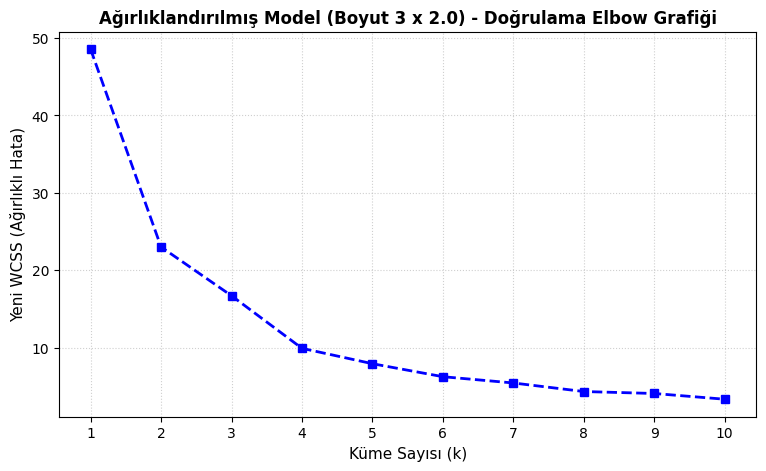


📊 4 Persona İçin Dağılım Sayıları:
Persona_Grubu
1    53
2    27
3    19
4    12
Name: count, dtype: int64
------------------------------------------------------------
🎯 Küme Merkezleri (Boyut 3 Değerleri 0-2 Arasında, Diğerleri 0-1):
               Boyut1_Niyet_Suruculer  Boyut2_Finansal_Hacim  \
Persona_Grubu                                                  
1                            0.036950               0.006289   
2                            0.695602               0.419753   
3                            0.103070               0.070175   
4                            0.740451               0.722222   

               Boyut3_Psikososyal_Yikim  
Persona_Grubu                            
1                              0.118423  
2                              0.484192  
3                              0.892597  
4                              1.422764  
------------------------------------------------------------


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# ===================================================================
# ADIM 1: SÜTUN SEÇİMİ VE VERİ HAZIRLIĞI
# ===================================================================
# df_boyutlar içindeki adında 'Boyut' geçen tüm sütunları dinamik yakalıyoruz
hedef_sutunlar = [col for col in df_boyutlar.columns if 'Boyut' in col]
X_raw = df_boyutlar[hedef_sutunlar].copy()

# 3'lü/4'lü şık dengesizliğini çözmek için 0-1 Normalizasyonu yapıyoruz
scaler = MinMaxScaler()
X_scaled_array = scaler.fit_transform(X_raw)
df_analiz_scaled = pd.DataFrame(X_scaled_array, columns=hedef_sutunlar, index=df_boyutlar.index)

# ===================================================================
# ADIM 2: BOYUT 3'E DİNAMİK OLARAK 2.0 AĞIRLIĞI VERME
# ===================================================================
for col in df_analiz_scaled.columns:
    if 'Boyut3' in col or 'Yikim' in col:
        df_analiz_scaled[col] = df_analiz_scaled[col] * 2.0
        print(f"⚡ {col} bulundu ve 2.0 katsayısıyla ağırlıklandırıldı.")

# Algoritmanın okuyacağı son matris formu
X_final_weighted = df_analiz_scaled[hedef_sutunlar].values

# ===================================================================
# ADIM 3: DOĞRULAMA İÇİN YENİ ELBOW GRAFİĞİNİ ÇİZDİRME
# ===================================================================
wcss_weighted = []
K_araligi = range(1, 11)

for k in K_araligi:
    kmeans_w = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_w.fit(X_final_weighted)
    wcss_weighted.append(kmeans_w.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(K_araligi, wcss_weighted, marker='s', linestyle='--', color='blue', linewidth=2)
plt.title('Ağırlıklandırılmış Model (Boyut 3 x 2.0) - Doğrulama Elbow Grafiği', fontsize=12, fontweight='bold')
plt.xlabel('Küme Sayısı (k)', fontsize=11)
plt.ylabel('Yeni WCSS (Ağırlıklı Hata)', fontsize=11)
plt.xticks(K_araligi)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# ===================================================================
# ADIM 4: K=4 İLE NİHAİ K-MEANS VE VERİ SETİNE KAYDETME
# ===================================================================
SECILEN_KUME_SAYISI = 4 
nihai_kmeans = KMeans(n_clusters=SECILEN_KUME_SAYISI, random_state=42, n_init='auto')
kume_etiketleri = nihai_kmeans.fit_predict(X_final_weighted)

# Katılımcıların hangi personaya ait olduğunu tüm tablolara eşliyoruz
df_boyutlar['Persona_Grubu'] = kume_etiketleri + 1
df_oyuncular['Persona_Grubu'] = kume_etiketleri + 1
df_analiz_scaled['Persona_Grubu'] = kume_etiketleri + 1

print(f"\n📊 {SECILEN_KUME_SAYISI} Persona İçin Dağılım Sayıları:")
print(df_boyutlar['Persona_Grubu'].value_counts().sort_index())
print("-" * 60)

print("🎯 Küme Merkezleri (Boyut 3 Değerleri 0-2 Arasında, Diğerleri 0-1):")
kume_ozeti = df_analiz_scaled.groupby('Persona_Grubu')[hedef_sutunlar].mean()
print(kume_ozeti)
print("-" * 60)

# ===================================================================
# ADIM 5: 3D ETKİLEŞİMLİ GÖRSELLEŞTİRME (PLOTLY)
# ===================================================================
# Persona isimlerini renklendirme için string yapıyoruz
df_analiz_scaled['Persona_Ismi'] = 'Persona ' + df_analiz_scaled['Persona_Grubu'].astype(str)

fig = px.scatter_3d(
    df_analiz_scaled, 
    x='Boyut1_Niyet_Suruculer', 
    y='Boyut2_Finansal_Hacim', 
    z='Boyut3_Psikososyal_Yikim',
    color='Persona_Ismi',
    title='🎯 Ağırlıklandırılmış (Boyut 3 x 2.0) Etkileşimli 3D Persona Uzayı',
    labels={
        'Boyut1_Niyet_Suruculer': 'Boyut 1: Niyet (0-1)',
        'Boyut2_Finansal_Hacim': 'Boyut 2: Finans (0-1)',
        'Boyut3_Psikososyal_Yikim': 'Boyut 3: Yıkım / Risk (0-2)'
    },
    opacity=0.85,
    color_discrete_sequence=px.colors.qualitative.Vivid
)

# Nokta büyüklüklerini ayarlayalım ve grafiği ekrana basalım
fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))
fig.show()

In [11]:
import os
import joblib

# --- 1. KAYIT YOLUNUN BELİRLENMESİ ---
# Proje yapındaki 'models' klasörünün yolunu tanımlıyoruz
models_klasor_yolu = '../../models'

# Eğer klasör yoksa otomatik oluşturma
if not os.path.exists(models_klasor_yolu):
    os.makedirs(models_klasor_yolu)
    print(f"📁 '{models_klasor_yolu}' klasörü oluşturuldu.")

# --- 2. DOSYA ADLARININ TANIMLANMASI ---
scaler_kayit_yolu = os.path.join(models_klasor_yolu, 'anivia_oyuncu_persona.pkl')
kmeans_kayit_yolu = os.path.join(models_klasor_yolu, 'player_clusters.pkl')

# --- 3. SERIALIZATION (PKL OLARAK KAYDETME) İŞLEMİ ---
# Scaler ve K-Means modellerini diske yazıyoruz
joblib.dump(scaler, scaler_kayit_yolu)
joblib.dump(nihai_kmeans, kmeans_kayit_yolu)

print("=" * 60)
print(f"✅ BAŞARILI: Scaler nesnesi kaydedildi:")
print(f"   📄 {scaler_kayit_yolu}")
print(f"\n✅ BAŞARILI: K-Means modeli kaydedildi:")
print(f"   📄 {kmeans_kayit_yolu}")
print("=" * 60)

✅ BAŞARILI: Scaler nesnesi kaydedildi:
   📄 ../../models\anivia_oyuncu_persona.pkl

✅ BAŞARILI: K-Means modeli kaydedildi:
   📄 ../../models\player_clusters.pkl


In [12]:
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier
import pandas as pd

# ===================================================================
# ADIM 1: VERİ SIZINTISINI (DATA LEAKAGE) ÖNLEME
# ===================================================================
# Hedef değişkenimiz (y)
y = df_oyuncular['Persona_Grubu']

# df_boyutlar içinde olan (Boyut hesaplamaları ve Persona_Grubu) tüm sütunları 
# df_oyuncular'dan çıkararak saf özellikleri (X) bırakıyoruz.
cikarilacak_sutunlar = [col for col in df_boyutlar.columns if col in df_oyuncular.columns]

# DİKKAT: Boyutları hesaplarken kullandığın HAM ANKET SORULARI da X'in içindeyse 
# model yine %100 kopya çeker. (Örn: oyuncu_harcama_butcesi, oyuncu_stres_etkisi vb.)
# Akademik tutarlılık için hedefi oluşturan o ham sütunları da X'ten çıkarmalısın.
# Aşağıdaki listeye o ham sütun adlarını ekleyebilirsin:
kopya_cektiren_ham_sutunlar = [
    'oyuncu_motivasyon', 
    'oyuncu_harcama_amaci', 
    'oyuncu_harcama_butcesi',
    'oyuncu_stres_etkisi', 
    'oyuncu_uyku_feragati', 
    'oyuncu_harcama_etkisi'
]

# Sütunları güvenli bir şekilde silme (Eğer listedeki sütun tabloda varsa siler)
tum_silinecekler = list(set(cikarilacak_sutunlar + kopya_cektiren_ham_sutunlar))
mevcut_silinecekler = [col for col in tum_silinecekler if col in df_oyuncular.columns]

X = df_oyuncular.drop(columns=mevcut_silinecekler)

print(f"✅ Modellemeye Giren Saf Bağımsız Değişkenler (Features): {list(X.columns)}\n")

# ===================================================================
# ADIM 2: TRAIN-TEST SPLIT (VERİYİ BÖLME)
# ===================================================================
# Veriyi %80 Eğitim, %20 Test olacak şekilde bölüyoruz. 
# stratify=y kullanıyoruz ki her persona grubu eğitim ve teste dengeli dağılsın.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ===================================================================
# ADIM 3: LAZYPREDICT İLE 30+ MODELİ YARIŞTIRMA
# ===================================================================
print("⏳ LazyPredict çalışıyor, tüm sınıflandırma algoritmaları yarışıyor...\n")

# LazyClassifier nesnesini oluştur (Kategorik verileri vs. otomatik halleder)
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

# Modelleri eğit ve test et
models_summary, predictions = clf.fit(X_train, X_test, y_train, y_test)

# ===================================================================
# ADIM 4: SONUÇLARI GÖRÜNTÜLEME
# ===================================================================
print("🏆 MODELLERİN LİDERLİK TABLOSU:")
print("=" * 70)
print(models_summary)

✅ Modellemeye Giren Saf Bağımsız Değişkenler (Features): ['oyuncu_yas', 'oyuncu_gunluk_sure', 'oyuncu_maglubiyet_tepkisi', 'oyuncu_ruh_hali', 'oyuncu_pegi_dikkat', 'oyuncu_platform_kisitlama_gorus', 'oyuncu_haftalik_oyun_gunu', 'oyuncu_ebeveyn_onay_gorus', 'oyuncu_cinsiyet_Erkek', 'oyuncu_cinsiyet_Kadın', 'oyuncu_harcama_etkisi_limit_asar_sarsmaz', 'oyuncu_harcama_etkisi_butce_zorlar', 'oyuncu_harcama_etkisi_hic_harcamaz', 'oyuncu_harcama_etkisi_pisman_gizler', 'oyuncu_stres_etkisi_notr', 'oyuncu_stres_etkisi_rahatlatir', 'oyuncu_stres_etkisi_oynamazsa_gergin', 'oyuncu_stres_etkisi_tam_rahatlatir', 'oyuncu_stres_etkisi_rekabet_stresi', 'oyuncu_harcama_amaci_yapmaz', 'oyuncu_harcama_amaci_hizli_ilerleme_guc', 'oyuncu_harcama_amaci_dogrudan_esya', 'oyuncu_harcama_amaci_sansa_dayali_kutu', 'oyuncu_motivasyon_kacis', 'oyuncu_motivasyon_rekabet', 'oyuncu_motivasyon_eglence', 'oyuncu_motivasyon_sosyallesme', 'oyuncu_oyun_turu_basit_eglence', 'oyuncu_oyun_turu_hayatta_kalma', 'oyuncu_oyun_tur

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report
import pandas as pd

print("="*70)
print("⚙️ DÜZELTİLMİŞ ADIM: ENCODING VE HİPERPARAMETRE OPTİMİZASYONU")
print("="*70)

# ===================================================================
# 1. KRİTİK DÜZELTME: TÜM METİNLERİ SAYISALLAŞTIRMA (ONE-HOT ENCODING)
# ===================================================================
# 'Kesinlikle destekliyorum' gibi metinleri 1 ve 0'lardan oluşan yeni sütunlara böleriz.
X_encoded = pd.get_dummies(X, drop_first=True)

print(f"✅ Metinler başarıyla sayısallaştırıldı. Yeni özellik sayısı: {X_encoded.shape[1]}")

# ===================================================================
# 2. VERİYİ BÖLME (X yerine X_encoded kullanıyoruz!)
# ===================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# ===================================================================
# 3. RANDOM FOREST OPTİMİZASYONU (GRID SEARCH)
# ===================================================================
rf_base = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 4, 7, 10],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None]
}

grid_search = GridSearchCV(
    estimator=rf_base, 
    param_grid=param_grid, 
    cv=5,                             
    scoring='f1_macro',               
    n_jobs=-1,                        
    verbose=1                         
)

print("⏳ Grid Search sayısallaştırılmış veriyle çalışıyor...\n")
grid_search.fit(X_train, y_train)

# ===================================================================
# 4. SONUÇLAR
# ===================================================================
print("🏆 OPTİMİZASYON TAMAMLANDI!")
print("-" * 50)
print(f"En İyi Parametreler: {grid_search.best_params_}")

best_rf_model = grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test)

print("\n📊 OPTİMİZE EDİLMİŞ NİHAİ MODEL RAPORU:")
print(classification_report(y_test, y_pred_tuned))

⚙️ DÜZELTİLMİŞ ADIM: ENCODING VE HİPERPARAMETRE OPTİMİZASYONU
✅ Metinler başarıyla sayısallaştırıldı. Yeni özellik sayısı: 39
⏳ Grid Search sayısallaştırılmış veriyle çalışıyor...

Fitting 5 folds for each of 72 candidates, totalling 360 fits
🏆 OPTİMİZASYON TAMAMLANDI!
--------------------------------------------------
En İyi Parametreler: {'class_weight': 'balanced', 'max_depth': 4, 'min_samples_split': 10, 'n_estimators': 50}

📊 OPTİMİZE EDİLMİŞ NİHAİ MODEL RAPORU:
              precision    recall  f1-score   support

           1       0.89      0.73      0.80        11
           2       0.67      0.67      0.67         6
           3       0.60      0.75      0.67         4
           4       0.33      0.50      0.40         2

    accuracy                           0.70        23
   macro avg       0.62      0.66      0.63        23
weighted avg       0.73      0.70      0.71        23



In [14]:
import joblib
import os

print("="*70)
print("💾 ANIVIA PERSONA MODELİ CANLIYA ALINIYOR (STREAMLIT)")
print("="*70)

# Klasör yolunu belirliyoruz ve yoksa oluşturuyoruz
models_klasor_yolu = '../../models'
os.makedirs(models_klasor_yolu, exist_ok=True)

# 1. Şampiyon Modeli Kaydetme (İstediğin isimle)
model_dosya_yolu = f"{models_klasor_yolu}/anivia_persona_classification.pkl"
joblib.dump(best_rf_model, model_dosya_yolu)

# 2. KRİTİK: Streamlit arayüzünde 'get_dummies' sütun uyuşmazlığını 
# önlemek için modelin eğitimde gördüğü tüm sütun isimlerini kaydediyoruz.
beklenen_sutunlar = list(X_train.columns)
sutun_dosya_yolu = f"{models_klasor_yolu}/anivia_persona_features.pkl"
joblib.dump(beklenen_sutunlar, sutun_dosya_yolu)

print(f"✅ Şampiyon Model başarıyla kaydedildi: {model_dosya_yolu}")
print(f"✅ Özellik Listesi başarıyla kaydedildi: {sutun_dosya_yolu}")
print("🚀 Streamlit Sekme 2 (Oyuncu Personaları) entegrasyonuna tamamen hazırız!")

💾 ANIVIA PERSONA MODELİ CANLIYA ALINIYOR (STREAMLIT)
✅ Şampiyon Model başarıyla kaydedildi: ../../models/anivia_persona_classification.pkl
✅ Özellik Listesi başarıyla kaydedildi: ../../models/anivia_persona_features.pkl
🚀 Streamlit Sekme 2 (Oyuncu Personaları) entegrasyonuna tamamen hazırız!
